In [79]:
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO

import os
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from tqdm import tqdm

# Define transformations (optional)
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

import gc

In [17]:
# Path to the annotation file
annotation_file = "/kaggle/input/segmentation-dataset/result.json"
image_folder = "/kaggle/input/segmentation-dataset/"

# Load COCO annotations
coco = COCO(annotation_file)

# Get all image IDs
image_ids = coco.getImgIds()

# Split dataset into training and validation sets (e.g., 80% train, 20% validation)
train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)


class COCOSegmentationDataset(Dataset):
    def __init__(self, coco, image_folder, image_ids, transforms=None):
        self.coco = coco
        self.image_folder = image_folder
        self.image_ids = image_ids
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=False)
        annotations = self.coco.loadAnns(ann_ids)
        
        # Load image
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.image_folder, img_info["file_name"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply transformations
        if self.transforms:
            transformed = self.transforms(image=image)
            image = transformed['image']
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        
        # Create segmentation mask
        mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
        boxes = []
        labels = []
        
        for ann in annotations:
            segmentation = ann["segmentation"]
            for seg in segmentation:
                pts = np.array(seg, dtype=np.int32).reshape(-1, 2)
                cv2.fillPoly(mask, [pts], color=1)
            
            # Get bounding box
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])
        
        # Convert boxes and labels to tensors
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        mask = torch.tensor(mask, dtype=torch.uint8)
        
        # Handle empty annotations
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            mask = torch.zeros((img_info["height"], img_info["width"]), dtype=torch.uint8)
        
        # Correct box shape handling
        boxes = boxes.view(-1, 4)  # Ensure shape is [N, 4]
        
        # Create target dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": mask.unsqueeze(0),  # Add batch dimension
        }
        
        return image, target

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [18]:
transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [19]:
# Create training and validation datasets
train_dataset = COCOSegmentationDataset(coco, image_folder, train_ids, transforms=transform)
val_dataset = COCOSegmentationDataset(coco, image_folder, val_ids, transforms=transform)

# Create DataLoader for training and validation
train_loader = DataLoader(
    train_dataset, 
    batch_size=3, 
    shuffle=True, 
    num_workers=2,  # Use >0 for parallel data loading
    pin_memory=True  # Optimizes memory transfer for GPU training
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=3, 
    shuffle=False, 
    num_workers=2,  # Use >0 for parallel data loading
    pin_memory=True  # Optimizes memory transfer for GPU training
)

In [ ]:
from torchvision.models.detection.mask_rcnn import MaskRCNN_ResNet50_FPN_Weights

# Load a pre-trained Mask R-CNN model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1  # Use COCO pre-trained weights
)

# Modify the box predictor for your number of classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes=2  # 1 class (document) + background
)

# Modify the mask predictor for your number of classes
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, num_classes=2
)

# If you want to load your existing bounding box weights
if False:  # Set to True if you want to use your existing weights
    # Load your trained model state dict
    model_path = '/kaggle/input/ecg-object-detection-model/pytorch/default/1/trained_ecg_object_detection_model.pth'
    trained_dict = torch.load(model_path, weights_only=True)
    
    # Copy only the backbone and box predictor weights
    model_dict = model.state_dict()
    for k in trained_dict.keys():
        if k.startswith('backbone.') or k.startswith('roi_heads.box_predictor.'):
            model_dict[k] = trained_dict[k]
    
    model.load_state_dict(model_dict)

# Move to GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
model.to(device)
print(f"Device: {device}")

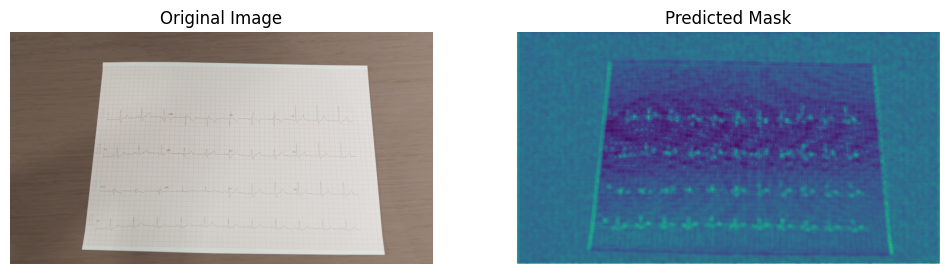

In [58]:
# Extract predictions for a single image: How do we do?

# Run model on a single example to see whether it produces a sensible mask 
model.eval()
img = cv2.imread('/kaggle/input/segmentation-dataset/images/0cd29213-50165e5a-train_000652.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
transformed = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])
input_tensor = transformed(img).unsqueeze(0).to(device)

with torch.no_grad(): 
    predictions = model(input_tensor)
    
predicted_masks = predictions[0]["masks"]  # Shape: (num_objects, 1, H, W)
scores = predictions[0]["scores"]  # Confidence scores
labels = predictions[0]["labels"]  # Object labels (should be 1 for ECG)

# Set confidence threshold
CONF_THRESH = 0.5

# Select the best mask (highest confidence)
if len(scores) > 0:
    best_mask_idx = torch.argmax(scores)  # Index of highest confidence mask
    if scores[best_mask_idx] > CONF_THRESH:
        mask = predicted_masks[best_mask_idx, 0].cpu().numpy()  # Convert to NumPy
        mask = (mask > 0.5).astype(np.uint8)  # Binarize mask (threshold = 0.5)

        # Resize mask to match image size
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

        # Overlay mask on image (red mask)
        overlay = img.copy()
        overlay[mask == 1] = [255, 0, 0]  # Red color for segmentation mask

        # Display results
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img)
        ax[0].set_title("Original Image")
        ax[1].imshow(mask, cmap="gray")
        ax[1].set_title("Predicted Mask")
        ax[2].imshow(overlay)
        ax[2].set_title("Mask Overlay on Image")

        for a in ax:
            a.axis("off")

        plt.show()
    else:
        print("No high-confidence mask detected.")
else:
    print("No objects detected.")

In [42]:
from torchvision.models.detection.mask_rcnn import MaskRCNN_ResNet50_FPN_Weights

# Load a pre-trained Mask R-CNN model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1  # Use COCO pre-trained weights
)

# Modify the box predictor for your number of classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes=2  # 1 class (document) + background
)

# Modify the mask predictor for your number of classes
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, num_classes=2
)

# If you want to load your existing bounding box weights
if True:  # Set to True if you want to use your existing weights
    # Load your trained model state dict
    model_path = '/kaggle/input/ecg-object-detection-model/pytorch/default/1/trained_ecg_object_detection_model.pth'
    trained_dict = torch.load(model_path, weights_only=True)
    
    # Copy only the backbone and box predictor weights
    model_dict = model.state_dict()
    for k in trained_dict.keys():
        if k.startswith('backbone.') or k.startswith('roi_heads.box_predictor.'):
            model_dict[k] = trained_dict[k]
    
    model.load_state_dict(model_dict)

# Move to GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
model.to(device)
print(f"Device: {device}")

Device: cuda


torch.Size([1, 3, 1900, 3460])


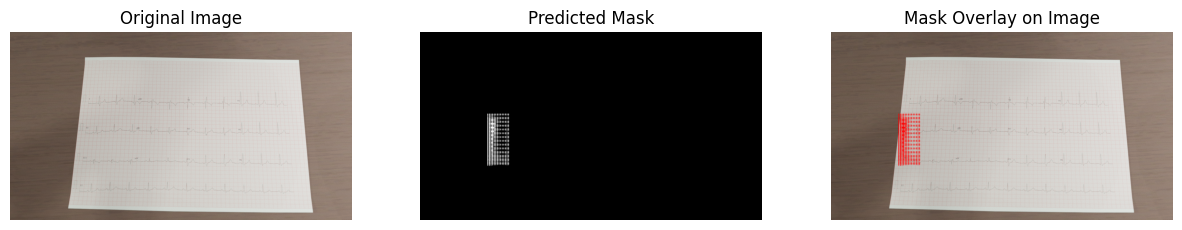

In [43]:
# Extract predictions for a single image: How do we do?

# Run model on a single example to see whether it produces a sensible mask 
model.eval()
img = cv2.imread('/kaggle/input/segmentation-dataset/images/0cd29213-50165e5a-train_000652.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
transformed = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])
input_tensor = transformed(img).unsqueeze(0).to(device)
print(input_tensor.shape)

with torch.no_grad(): 
    predictions = model(input_tensor)

predicted_masks = predictions[0]["masks"]  # Shape: (num_objects, 1, H, W)
scores = predictions[0]["scores"]  # Confidence scores
labels = predictions[0]["labels"]  # Object labels (should be 1 for ECG)

# Set confidence threshold
CONF_THRESH = 0.5

# Select the best mask (highest confidence)
if len(scores) > 0:
    best_mask_idx = torch.argmax(scores)  # Index of highest confidence mask
    if scores[best_mask_idx] > CONF_THRESH:
        mask = predicted_masks[best_mask_idx, 0].cpu().numpy()  # Convert to NumPy
        mask = (mask > 0.5).astype(np.uint8)  # Binarize mask (threshold = 0.5)

        # Resize mask to match image size
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

        # Overlay mask on image (red mask)
        overlay = img.copy()
        overlay[mask == 1] = [255, 0, 0]  # Red color for segmentation mask

        # Display results
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img)
        ax[0].set_title("Original Image")
        ax[1].imshow(mask, cmap="gray")
        ax[1].set_title("Predicted Mask")
        ax[2].imshow(overlay)
        ax[2].set_title("Mask Overlay on Image")

        for a in ax:
            a.axis("off")

        plt.show()
    else:
        print("No high-confidence mask detected.")
else:
    print("No objects detected.")

In [31]:
mask.sum()

629556

In [22]:
def freeze_backbone(model):
    """Freeze all backbone layers"""
    for param in model.backbone.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    """Unfreeze all backbone layers"""
    for param in model.backbone.parameters():
        param.requires_grad = True

In [23]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


In [24]:
def process_targets(targets, images): 
    
    # Process targets - handle the batched format
    if len(targets["boxes"]) > 0:
        # Remove the extra dimension (batch_size, 1, 4) -> (batch_size, 4)
        targets["boxes"] = targets["boxes"].squeeze(1)
        targets["labels"] = targets["labels"].squeeze(1) if targets["labels"].dim() > 1 else targets["labels"]
        # For masks, keep the proper dimensions for batch processing
        if targets["masks"].dim() > 3:
            targets["masks"] = targets["masks"].squeeze(1)
    else:
        print("No bounding boxes in this target!")
        return None, None, True
    
    # Move targets to device
    targets = {k: v.to(device) for k, v in targets.items()}
    
    # Prepare list of dictionaries for each item in batch
    target_list = []
    for i in range(len(images)):
        target_dict = {
            'boxes': targets['boxes'][i].unsqueeze(0),  # [1, 4]
            'labels': targets['labels'][i].unsqueeze(0),  # [1]
            'masks': targets['masks'][i].float().unsqueeze(0)    # [1, H, W]
        }
        target_list.append(target_dict)

    return targets, target_list, False

In [25]:
def train_model(model, dataloader, num_epochs=10, initial_lr=1e-5, device="cuda", 
                patience=5, unfreeze_epoch=3):
    model.to(device)
    
    # Start with frozen backbone
    freeze_backbone(model)
    print("Backbone frozen for initial training")
    
    # Initialize optimizer with low learning rate
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                               lr=initial_lr)
    
    # Initialize early stopping
    early_stopping = EarlyStopping(patience=patience)
    
    # Track losses for plotting
    all_losses = []
    loss_components = {
        'loss_classifier': [],
        'loss_box_reg': [],
        'loss_objectness': [],
        'loss_rpn_box_reg': [],
        'loss_mask': []
    }

    all_train_metrics = []
    all_val_metrics = []
    
    for epoch in range(num_epochs):
        
        # Model training 
        
        model.train()
        epoch_loss = 0
        epoch_component_losses = {k: 0 for k in loss_components.keys()}
        n_batches = len(dataloader)
        
        # Unfreeze backbone if we've reached the specified epoch
        if epoch == unfreeze_epoch:
            print(f"\nEpoch {epoch + 1}: Unfreezing backbone")
            unfreeze_backbone(model)
            # Update optimizer to include unfrozen parameters
            optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr/10)
        
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
        
        for images, targets in progress_bar:
            # Move images to device
            images = [img.to(device) for img in images]
            targets, target_list, skip = process_targets(targets, images)

            if (skip): 
                continue 

            # Forward pass with properly formatted targets
            loss_dict = model(images, target_list)
            
            # Calculate total loss and component losses
            total_loss = sum(loss for loss in loss_dict.values())
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            # Update losses
            epoch_loss += total_loss.item()
            for k, v in loss_dict.items():
                epoch_component_losses[k] += v.item()
            
            # Update progress bar
            progress_bar.set_postfix(loss=epoch_loss / (progress_bar.n + 1))
        
        # Calculate average losses for this epoch
        avg_epoch_loss = epoch_loss / n_batches
        all_losses.append(avg_epoch_loss)
        
        # Calculate and store average component losses
        for k in loss_components.keys():
            avg_component_loss = epoch_component_losses[k] / n_batches
            loss_components[k].append(avg_component_loss)
        
        # Print detailed loss breakdown
        print(f"\nEpoch {epoch + 1} finished with:")
        print(f"Total loss: {avg_epoch_loss:.4f}")
        for k, v in epoch_component_losses.items():
            print(f"{k}: {v/n_batches:.4f}")
        
        # Early stopping check
        early_stopping(avg_epoch_loss)
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered after epoch {epoch + 1}")
            break

        # Model validation 

        #model.eval() 
        val_loss = 0 
        val_component_losses = {k: 0 for k in loss_components.keys()}
        all_predictions = []
        all_ground_truth = []

        with torch.no_grad():  # Disable gradient calculations during validation
            for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)", leave=True):
                images = [img.to(device) for img in images]
                targets, target_list, skip = process_targets(targets, images)
                
                if (skip): 
                    continue 

                model.train()
                # Forward pass with properly formatted targets
                loss_dict = model(images, target_list)

                return loss_dict
                
                # Calculate total loss and component losses
                total_loss = sum(loss for loss in loss_dict.values())
                val_loss += total_loss.item()
                
                # Update component losses
                for k, v in loss_dict.items():
                    val_component_losses[k] += v.item()
                
                # Collect predictions for metrics computation
                for i in range(len(images)):
                    pred_masks = loss_dict['masks'][i].cpu().numpy()
                    gt_masks = targets['masks'][i].cpu().numpy()
                    
                    # Store the masks and compute IoU (intersection over union)
                    all_predictions.append(pred_masks)
                    all_ground_truth.append(gt_masks)
        
        # Calculate average validation losses for this epoch
        avg_val_loss = val_loss / len(val_loader)
        print(f"\nValidation loss: {avg_val_loss:.4f}")
        
        # Calculate and store average component validation losses
        for k in loss_components.keys():
            avg_component_val_loss = val_component_losses[k] / len(val_loader)
            print(f"{k} (Val): {avg_component_val_loss:.4f}")
        
        # Compute IoU and other metrics for the validation set
        iou_scores = compute_iou(all_predictions, all_ground_truth, iou_threshold=iou_threshold)
        precision, recall, f1, _ = precision_recall_fscore_support(all_ground_truth, all_predictions, average='binary')
        
        val_metrics = {
            'iou': np.mean(iou_scores),
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }
        all_val_metrics.append(val_metrics)
        
        # Print validation metrics
        print(f"Validation Metrics - IoU: {val_metrics['iou']:.4f}, Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, F1 Score: {val_metrics['f1_score']:.4f}")


    print("\nTraining complete!")
    return all_losses, loss_components, all_train_metrics, all_val_metrics

In [26]:
print("Mask predictor:", model.roi_heads.mask_predictor)
print("Number of classes:", model.roi_heads.mask_predictor.mask_fcn_logits.out_channels)

Mask predictor: MaskRCNNPredictor(
  (conv5_mask): ConvTranspose2d(256, 256, kernel_size=(2, 2), stride=(2, 2))
  (relu): ReLU(inplace=True)
  (mask_fcn_logits): Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))
)
Number of classes: 2


In [27]:
# [{'boxes': tensor([[ 241.4051,  329.4469, 3036.0239, 1746.6367]], device='cuda:0'), 'labels': tensor([0], device='cuda:0'), 'masks': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          ...,
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')}, {'boxes': tensor([[ 571.3173,  171.9578, 3063.9758, 1813.3735]], device='cuda:0'), 'labels': tensor([0], device='cuda:0'), 'masks': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          ...,
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')}, {'boxes': tensor([[ 362.1785,  109.2284, 3015.2798, 1753.4039]], device='cuda:0'), 'labels': tensor([0], device='cuda:0'), 'masks': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          ...,
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.],
#          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')}]

In [28]:
# # Train model (new)
# losses, comp_losses, train_metrics, val_metrics = \
#     train_model(model, train_loader, num_epochs=2, device=device, initial_lr=1e-5, patience=5, unfreeze_epoch=3)

loss_dict = train_model(model, train_loader, num_epochs=2, device=device, initial_lr=1e-5, patience=5, unfreeze_epoch=3)

Backbone frozen for initial training


Epoch 1/2: 100%|██████████| 24/24 [00:19<00:00,  1.26it/s, loss=0.245]



Epoch 1 finished with:
Total loss: 0.2453
loss_classifier: 0.1954
loss_box_reg: 0.0000
loss_objectness: 0.0321
loss_rpn_box_reg: 0.0178
loss_mask: 0.0000


Epoch 1/2 (Val):   0%|          | 0/6 [00:02<?, ?it/s]


In [29]:
loss_dict

{'loss_classifier': tensor(0.0132, device='cuda:0'),
 'loss_box_reg': tensor(0., device='cuda:0'),
 'loss_mask': tensor(0., device='cuda:0'),
 'loss_objectness': tensor(0.0484, device='cuda:0'),
 'loss_rpn_box_reg': tensor(0.0225, device='cuda:0')}

In [30]:
# def train_model_old(model, dataloader, optimizer, num_epochs=10, device="cuda"):
#     model.to(device)  # Move model to the correct device
#     model.train()  # Set model to training mode
    
#     for epoch in range(num_epochs):
#         epoch_loss = 0
#         progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
        
#         for images, targets in progress_bar:
#             # Move images to the correct device
#             images = [img.to(device) for img in images]

#             # Squeeze unnecessary dimensions for boxes, labels, and masks
#             if len(targets["boxes"]) > 0:
#                 targets["boxes"] = targets["boxes"].squeeze(0)  # Remove batch dimension
#                 if targets["boxes"].dim() == 1:  # If we end up with a 1D tensor, reshape to [1, 4]
#                     targets["boxes"] = targets["boxes"].unsqueeze(0)  # Ensure shape is [1, 4]

#                 targets["labels"] = targets["labels"].squeeze(0)
#                 if targets["labels"].dim() == 0:  # If it's a scalar, reshape to [1]
#                     targets["labels"] = targets["labels"].unsqueeze(0)

#                 targets["masks"] = targets["masks"].squeeze(0)
#                 if targets["masks"].dim() == 2:  # If the mask is 2D, ensure it has the proper batch dimension
#                     targets["masks"] = targets["masks"].unsqueeze(0)  # Ensure shape is [1, H, W]
#             else:
#                 print("No bounding boxes in this target!")

#             # Move targets to the correct device
#             targets = {k: v.to(device) for k, v in targets.items()}

#             # Forward pass: Get the loss
#             loss_dict = model(images, [targets])  # Wrap targets into a list for a single batch
#             loss = sum(loss for loss in loss_dict.values())

#             # Backward pass: Compute gradients
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             # Track the loss
#             epoch_loss += loss.item()
#             progress_bar.set_postfix(loss=epoch_loss / len(dataloader))
        
#         # Print epoch loss
#         print(f"Epoch {epoch+1} finished with loss: {epoch_loss / len(dataloader):.4f}")
    
#     print("Training complete!")

#  # Define optimizer
# optimizer = torch.optim.Adam(mask_model.parameters(), lr=0.0001)

# # Train model
# train_model_old(mask_model, train_loader, optimizer, num_epochs=2, device=device)